In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column, unique
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm
import seaborn as sns
plt.rcParams['text.usetex'] = False
pf.housestyle_rcparams()

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', message='The following kwargs were not used by contour')

True

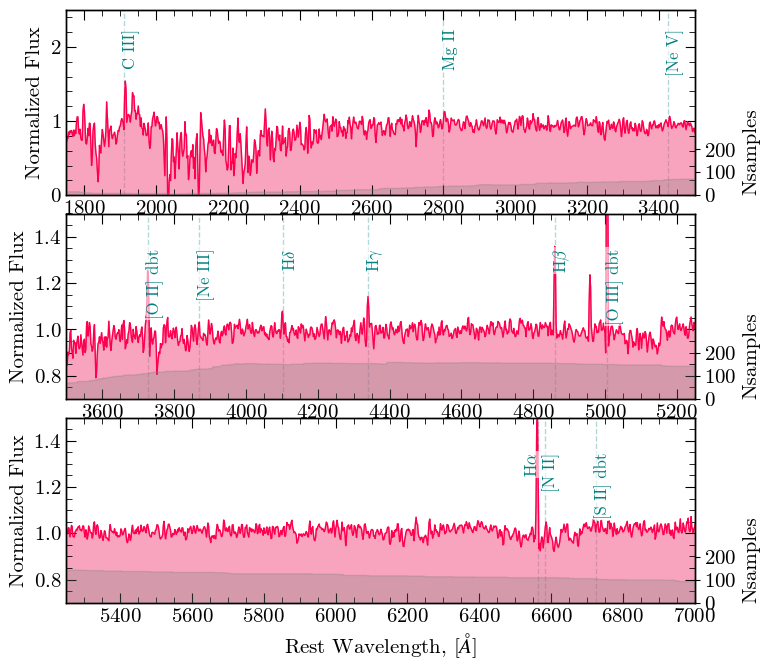

In [ ]:
tab = Table(fits.open('coadd_spectra.fits')[1].data)
rail = np.arange(620, 9500, 2)
grid = np.full((len(rail), len(tab)), np.nan)

for i, t in enumerate(tab):
    if len(t['Wavelength']) == 0:
        continue
        
    start_idx = np.searchsorted(rail, t['Wavelength'][0])
    
    end_idx = start_idx + len(t['Wavelength'])
    if end_idx <= len(rail):
        grid[start_idx:end_idx, i] = t['Flux']

coadd = np.nanmean(grid, axis=-1)/1e8
indicator = np.sum(~np.isnan(grid), axis=-1)

# Normalize the coadded spectrum so its median is 1
median_flux = np.nanmedian(coadd)
# if median_flux > 0:
coadd += (1-median_flux)

fig, axes = plt.subplots(3, 1, figsize=(8, 7))

wave_splits = np.linspace(1750, 7000, 4)
max_indicator = np.nanmax(indicator)
twins = []

# 1. Define the lines (Wavelength: Label)
# Updated Dictionary: (Wavelength: Label)
lines = {
    1216: r"Ly$\alpha$", 1549: "C IV", 1640: "He II", 1909: "C III]",
    2798: "Mg II", 3426: "[Ne V]", 3727: "[O II] dbt", 3869: "[Ne III]", 
    4102: r"H$\delta$", 4340: r"H$\gamma$", 4861: r"H$\beta$", 
    5007: "[O III] dbt", # Representing 4959/5007
    6563: r"H$\alpha$", 6584: "[N II]", 
    6724: "[S II] dbt"  # Midpoint of 6717/6731
}



axes[0].set_ylim(0,2.5)
axes[1].set_ylim(0.7,1.5)
axes[2].set_ylim(0.7,1.5)

for i, ax in enumerate(axes):
    start_wave, end_wave = wave_splits[i], wave_splits[i+1]
    
    # Filter lines for the current subplot range
    current_lines = {w: l for w, l in lines.items() if start_wave <= w <= end_wave}
    
    for line_wave, label in current_lines.items():
        # Draw the line
        ax.axvline(line_wave, color='teal', linestyle='--', alpha=0.3, lw=1, zorder=0)
        
        # Determine Y-position (using 90% of the current view)
        y_min, y_max = ax.get_ylim()
        y_pos = y_max * 0.9
        
        # Offset Logic for the H-alpha / [N II] cluster
        # If lines are within 40A of each other, nudge the text
        x_offset = 20
        if label == "[N II]":
            x_offset = 15 # Nudge [N II] to the right
        elif label == r"H$\alpha$":
            x_offset = -15 # Nudge H-alpha to the left
            
        ax.text(line_wave + x_offset, y_pos, label, rotation=90, 
                verticalalignment='top', horizontalalignment='center', 
                fontsize=12, color='teal', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

from scipy.signal import savgol_filter
coadd_plot = savgol_filter(coadd, window_length=5, polyorder=3)

# from spectres import spectres
# rail_coarse = np.arange(620, 9500, 10) # 10A bins instead of 2A
# coadd_plot = spectres(rail_coarse, rail, coadd)

for i, ax in enumerate(axes):
    start_wave, end_wave = wave_splits[i], wave_splits[i+1]
    
    idx = (rail >= start_wave) & (rail < end_wave)
    rail_slice = rail[idx]
    coadd_slice = coadd[idx]
    indicator_slice = indicator[idx]

    # ax.plot(rail_slice, coadd_slice, color='#ff004f', lw=1)
    # ax.fill_between(rail_slice, coadd_slice, 0, color="#f54a80", alpha=0.5)
    ax.plot(rail, coadd_plot, color='#ff004f', lw=1)
    ax.fill_between(rail, coadd_plot, 0, color="#f54a80", alpha=0.5)

    ax.set_ylabel("Normalized Flux")
    ax.set_xlim(start_wave, end_wave)
    ax.grid(False)

    if i == len(axes) - 1:
        ax.set_xlabel(r"Rest Wavelength, [$\AA$]")

    ax2 = ax.twinx()
    
    ax2.fill_between(rail_slice, indicator_slice, color='gray', alpha=0.3, step='pre')
    
    ax2.set_ylim(0, max_indicator * 5)
    ax2.set_ylabel("Nsamples", loc='bottom')
    ax2.set_yticks([0,100,200])
    twins.append(ax2)

fig.tight_layout()



fig.subplots_adjust(hspace=0.1)

pf.fix_plot(axes)
# pf.fix_plot(twins,tickdir='out')

In [117]:
tab

<Table length=248>
  ID  ...
int64 ...
----- ...
    4 ...
    7 ...
   15 ...
   18 ...
   41 ...
   42 ...
   43 ...
   45 ...
   49 ...
  ... ...
  249 ...
  251 ...
  252 ...
  253 ...
  255 ...
  279 ...
  284 ...
  288 ...
  319 ...
  320 ...